
# Differential Equations and Euler's method

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

# Differential equations

In first year calculus, we encounter equations involving functions and their derivatives. We call such equations **differential equations**. If equation contains only ordinary derivates we call it an **ordinary differential equation**, otherwise if the equation contains partial derivatives, we call it a **partial differential equation**.

You have probably seen one differential equation sometime in highschool. It is called *Newton's Second Law of Motion*. Newton's Second Law says that in order to accelarate a point mass $m$ at a rate of accelaration $a$, it requires a force $F$. That is,
$$ F= ma.$$

It is perhaps not immediately clear that this is a differential equation. However, if we let $a=\frac{dv}{dt}$ or $a=\frac{d^2x}{dt^2}$, then by writing force as a function of position and time we have the following equation:
$$F(t,x)=m\frac{d^2x}{dt^2}.$$

A **solution** to a differential equation (on some interval $(a,b)$) is a function which satisfies the differential equation (on the interval $(a,b)$). 

For example, $y(x)=x^{-3/2}$ is a solution to the differential equation
$$4x^2y''+12xy'+3y=0$$
for any $x>0$.

Sometimes a differential equation will come with additional constraints called **initial conditions**. For instance, we may specify that $y(x_0)=y_0$ and $y'(x_0)=y_1$. 

An **initial value problem** (**IVP**) is a differential equation together with some information about initial conditions.

# Why do we want to solve differential equations?

Differential equations appear often in the study of physical systems. In fact, most mathematical models we see in the sciences involve differential equations. In first year calculus, we see that some *nice* differential equations have exact solutions which we can obtain with methods such as: substitution; integration etc. However, it turns out that *most* differential equations cannot be solved by elementary methods. What can we do when we have differential equations that describe the behaviour of physical systems we are interested in, but we have no way of solving them exactly? 

We can solve them **numerically**! In this course we will learn about two methods for understanding the behaviour of differential equations numerical: Via graphing (vector fields) we can understand the long-term behaviour of differential equations for different initial conditions; Via Euler's method we can **approximate** a solution to a given IVP.

# Vector fields

We can gain knowledge about the long-term behaviour of a differential equation for multiple choices of initial values by constructing its associated vector field. The idea is to graph the direction and size of the derivative for every point on a plane.

# Example

Draw the vector field and describe the long term evolution of the following equation 
$$y'=(y^2-y-2)(1-y)^2.$$

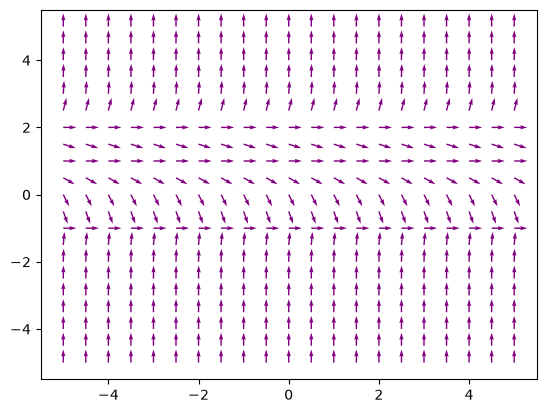

In [2]:
x = np.arange(-5,5.5,0.5) # x-axis goes from -5 to 5 with step size 0.5
y = np.arange(-5,5.5,0.5) # y-axis is drawn the same as the x-axis
X,Y = np.meshgrid(x,y) # create a grid of all (x,y) points in the above ranges

dy = (Y**2-Y-2)*(1-Y)**2 # plot y-derivative
dx = np.ones_like(dy) # since x is just the function x, its derivative is 1.
norm = np.sqrt(dx**2+dy**2) # normalize derivatives
dyu = dy/norm
dxu = dx/norm

plt.quiver(X,Y,dxu,dyu,color = "purple") # quiver allows us to plot a vector field
plt.show()

We can obtain the following information from the above plot:
- There are four long term behaviours of the system. Corresponding to the following initial conditions:
    - $y=\infty$
    - $y=2$
    - $y=1$
    - $y=-1$
- $y=-1$ is the only **stable** equilibrium (initial conditions close to $y=1$ will converge to this solution).

# Example 
Draw the vector field and describe the long term evolution of the following equation:
$$y'=y-x$$

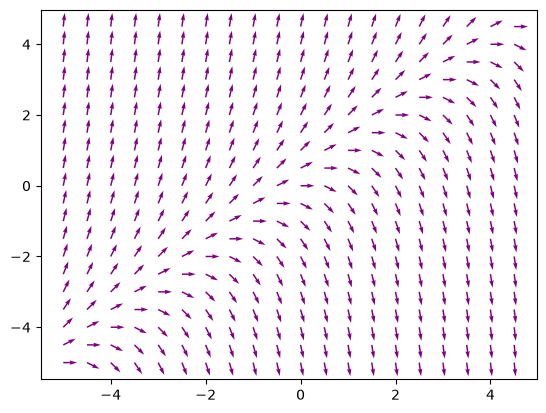

In [3]:
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(-5,5,0.5)
y = np.arange(-5,5,0.5)
X,Y = np.meshgrid(x,y)

dy = Y - X
dx = np.ones_like(dy)
norm = np.sqrt(dx**2+dy**2)
dyu = dy/norm
dxu = dx/norm

plt.quiver(X,Y,dxu,dyu,color = "purple")
plt.show()

### What can we say about the long-term behaviour of this equation?

# Euler's Method 

Given an initial value problem (IVP) of the form:

$$\frac{dx}{dt} = f(x,y,z,t)$$

$$\frac{dy}{dt} = f(x,y,z,t)$$

$$\frac{dz}{dt} = f(x,y,z,t)$$

and some initial values $x_0$, $y_0$, and $z_0$. We can solve the system by Euler's method by choosing some step size $h$, then $t_n=t_0+nh$, and 

$$ x_{n+1} = x_n + h*f(x_n,y_n,z_n,t_n)$$
$$ y_{n+1} = y_n + h*f(x_n,y_n,z_n,t_n)$$
$$ z_{n+1} = z_n + h*f(x_n,y_n,z_n,t_n)$$


**Example: Simple spring**  

We know from Hooke's law, that the force exerted on a spring is $F=-kx^2$. Thus, the change in $x$ as a function of time is $-kx/m$ by Newton's second law. So, we have the following initial value problem:

$$\frac{dx}{dt} = -kx/m$$


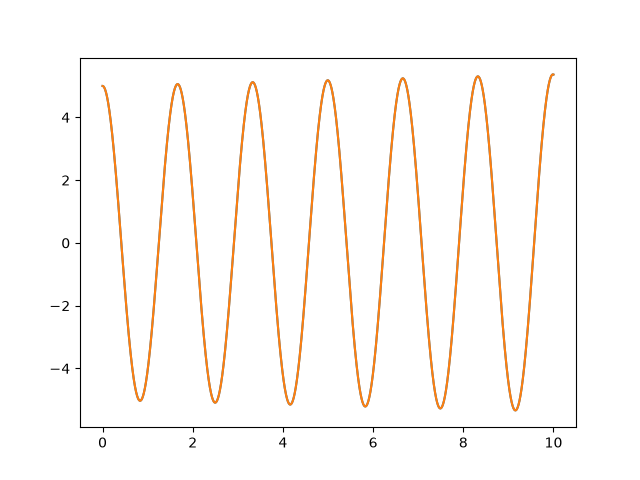

In [11]:
##Solve and graph using Euler's method:

# Constants
k = 2.85  # Spring constant
x0 = 5    # Initial position
v0 = 0    # Initial velocity (dx/dt)
h = 0.001 # Time step (Constant for Euler's method)
m = 0.2   # Mass

# Time array
t = np.arange(0, 10, h)  # 10 seconds with step size h

# Arrays to store position and velocity
xt = np.zeros_like(t)
vt = np.zeros_like(t)

# Initial conditions
xt[0] = x0
vt[0] = v0

# Euler's method loop
for i in range(len(t) - 1):
    a = -k * xt[i] / m  # Acceleration from Hooke's law a = dv/dt
    vt[i + 1] = vt[i] + h * a # Update velocity v = dx/dt
    xt[i + 1] = xt[i] + h * vt[i]  # Update position
plt.plot(t,xt)
plt.show()

**Lorentz System:** The Lorentz system (1963 "weather simulation") is the following IVP:

$$\frac{dx}{dt} = \sigma(y-x)$$
$$\frac{dy}{dt} = x(\rho - z)-y$$
$$\frac{dz}{dt} = xy - \beta z$$

In [32]:
# Specify parameters
sigma = 10
beta = 8 / 3
rho = 28
h = 0.001 # stepsize for Euler's method
t_end = 60 # time to end at
x_0 = y_0 = z_0 = 1

#package Euler's method as a function for ease of use!
def solve_lorenz_euler(sigma, beta, rho, x_0, y_0, z_0, h, t_end):
    # Time points
    t = np.arange(0, t_end, h)

    # Make arrays to store rabbit and fox populations
    x = np.zeros_like(t)
    y = np.zeros_like(t)
    z = np.zeros_like(t)

    # Set initial conditions
    x[0] = x_0
    y[0] = y_0
    z[0] = z_0

    # Write a for loop to keep updating r and f as time goes on
    for i in range(1, len(t)):
        x[i] = x[i - 1] + h * sigma * (y[i - 1] - x[i - 1])
        y[i] = y[i - 1] + h * (x[i - 1] * (rho - z[i - 1]) - y[i - 1])
        z[i] = z[i - 1] + h * (x[i - 1] * y[i - 1] - beta * z[i - 1])

    return t, x, y, z


t, x, y, z = solve_lorenz_euler(
    sigma, beta, rho, x_0, y_0, z_0, h, t_end
)

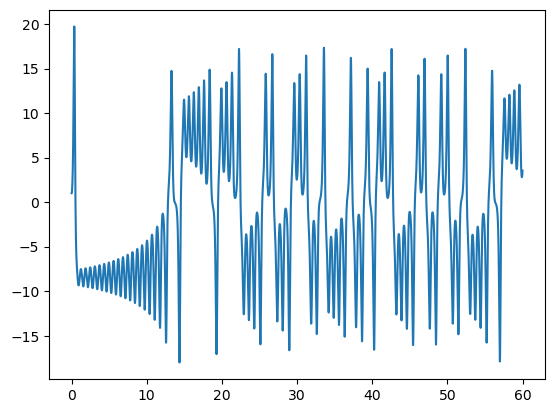

In [33]:
## plot the results

x = x[::10]
t = t[::10]

plt.plot(t,x)
plt.show()

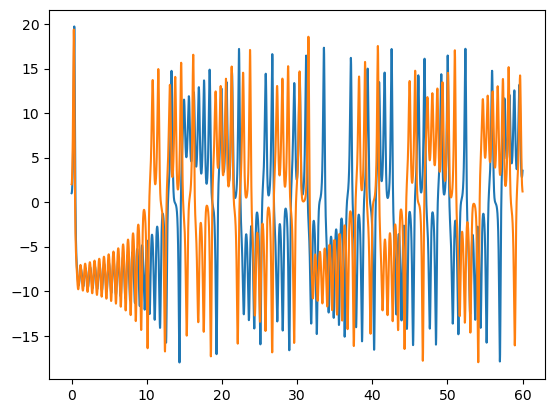

In [34]:
## Notice how sensitive the system is to a change in initial parameters:

tprime, xprime, y, z = solve_lorenz_euler(sigma,beta,rho,2,2,2,h,t_end)
t, x, y, z = solve_lorenz_euler(sigma,beta,rho,1,1,1,h,t_end)

xprime= xprime[::10]
tprime = tprime[::10]
x = x[::10]
t = t[::10]

plt.plot(t,x)
plt.plot(tprime,xprime)
plt.show()

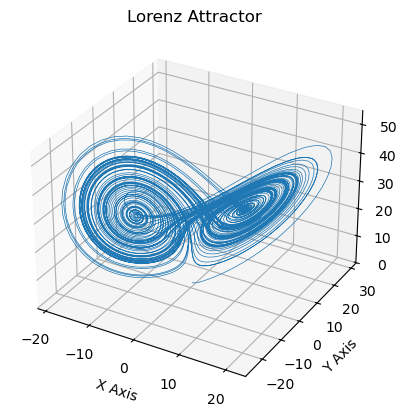

In [35]:
# From the matplotlib documentation

def lorenz(xyz, *, s=10, r=28, b=2.667):
    """
    Parameters
    ----------
    xyz : array-like, shape (3,)
       Point of interest in three-dimensional space.
    s, r, b : float
       Parameters defining the Lorenz attractor.

    Returns
    -------
    xyz_dot : array, shape (3,)
       Values of the Lorenz attractor's partial derivatives at *xyz*.
    """
    x, y, z = xyz # unpacking the arrays
    x_dot = s*(y - x) # defining the x,y, and z time derivatives.
    y_dot = r*x - y - x*z
    z_dot = x*y - b*z
    return np.array([x_dot, y_dot, z_dot]) #package the derivatives in a 2-dimensional array


dt = 0.01 # constant for Euler's method (the smaller the more accurate we will be but the longer the computation will take!)
num_steps = 10000

xyzs = np.empty((num_steps + 1, 3))  # Need one more for the initial values
xyzs[0] = (0., 1., 1.05)  # Set initial values
# Step through "time", calculating the partial derivatives at the current point
# and using them to estimate the next point
for i in range(num_steps): # Using Euler's method here!
    xyzs[i + 1] = xyzs[i] + lorenz(xyzs[i]) * dt

# Plot
ax = plt.figure().add_subplot(projection='3d')

ax.plot(*xyzs.T, lw=0.5)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor")

plt.show()

# Example 

Consider the following IVP
$$y'-y=-\frac{1}{2}e^{x/2}sin(5x)+5e^{x/2}cos(5x)$$
and $y(0)=0$.

Compare Euler's method at $x=1,2,3,4,5$ with $h=0.1,0.05,0.01$, and $h=0.001$ with the actual solution of 
$$y(x)=e^{x/2}sin(5x).$$

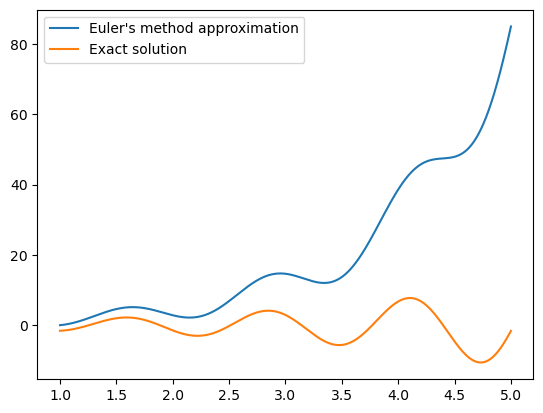

In [39]:
def y_prime(x,y):# y - derivative
    return -1/2*np.exp(x/2)*np.sin(5*x) + 5*np.exp(x/2)*np.cos(5*x)+y
def sol_y(x): # actual solution
    return np.exp(x/2)*np.sin(5*x)
h = 0.0001 #stepsize
x = np.arange(1,5,h)
y = np.zeros_like(x)
y0 = 0
y[0] = y0
sol = sol_y(x)

for i in range(len(x)):
    y[i] += y[i-1]+h*y_prime(x[i-1],y[i-1])
plt.plot(x,y,label="Euler's method approximation")
plt.plot(x,sol,label="Exact solution")
plt.legend()
plt.show()

# A discussion of Euler's method

Euler's method can be an incredibly helpful and simple numerical method for solving ordinary differential equations. However, as the previous example illustrates, for rapidly evolving differential equations, error will propagate very quickly.



# Modifications of Euler's method

The above example demonstrates one of the key issues with Euler's method: In rapidly evolving systems Euler's method will accumulate error rapidly. One popular modification of Euler's method aims to solve this problem it is called **Huen's method**.

# Huen's method

Huen's method operates on a similar iterative approach to Euler's method. However, the way we update at each step is slightly different. Given an IVP of the form $y'(t)=f(t,y(t))$ and $y(t_0)=y_0$, we may compute $y_i$ as follows:
$$\mathtt{temp}_{i}=y_{i-1}+h\times f(t_{i-1},y_{i-1})$$
where $\mathtt{temp}_i$ is some temporary variable to hold the approximation of $y_i$ given by Euler's method. Then,
$$y_i=y_{i-1}+\frac{h}{2}[f(t_{i-1},y_{i-1})+f(t_i,\mathtt{temp}_i)].$$

# Exercise

Recall the IVP from before.
$$y'-y=-\frac{1}{2}e^{x/2}sin(5x)+5e^{x/2}cos(5x)$$
and $y(0)=0$.

Compare Euler's method at $x=1,2,3,4,5$ with $h=0.1,0.05,0.01$, and $h=0.001$ with the actual solution of 
$$y(x)=e^{x/2}sin(5x).$$

Compare the solution obtained from Heun's method to that from Euler's method

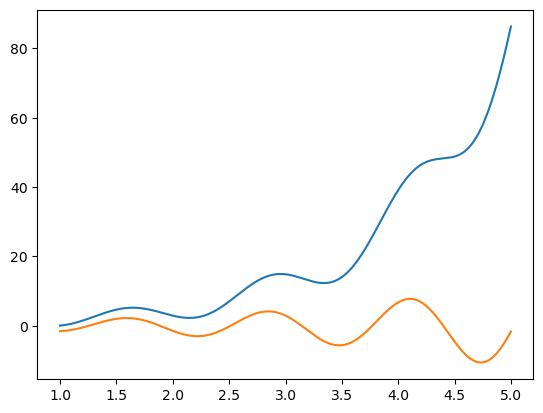

In [40]:
def y_prime(x,y):
    return -1/2*np.exp(x/2)*np.sin(5*x) + 5*np.exp(x/2)*np.cos(5*x)+y
def sol_y(x):
    return np.exp(x/2)*np.sin(5*x)
h = 0.001
x = np.arange(1,5,h)
heun_y = np.zeros_like(x)
temp = np.zeros_like(x) # add in new temp array
y0 = 0
heun_y[0] = y0
sol = sol_y(x)

for i in range(len(x)):
    temp[i] += heun_y[i-1]+h*y_prime(x[i-1],heun_y[i-1])
    heun_y[i] += heun_y[i-1]+(h/2)*(y_prime(x[i-1],heun_y[i-1])+y_prime(x[i],temp[i]))
plt.plot(x,heun_y,label="Euler's method approximation")
plt.plot(x,sol,label="Exact solution")
plt.show()

In [41]:
def y_prime(x,y):
    return -1/2*np.exp(x/2)*np.sin(5*x) + 5*np.exp(x/2)*np.cos(5*x)+y
def sol_y(x):
    return np.exp(x/2)*np.sin(5*x)
h = 0.001
x = np.arange(1,5,h)
y = np.zeros_like(x)
y0 = 0
y[0] = y0
sol = sol_y(x)

for i in range(len(x)):
    y[i] += y[i-1]+h*y_prime(x[i-1],y[i-1])

error1 = sum(abs(y-sol))
error2 = sum(abs(heun_y-sol))
print(f"The error from Euler's method was {error1},\n the error from Heun's method was {error2}.")

The error from Euler's method was 87835.15491805093,
 the error from Heun's method was 86419.18572605868.


# A discussion of numerical methods

Euler's method and Heun's method are actually both cases of what are called Runge-Kutta methods. **Runge-Kutta** methods are a family of methods for solving differential equations numerically. They all use the basic ideas of Euler's method but provide different degrees of accuracy (for increased computation time).

For example, the fourth order Runge-Kutta method (usually shortened as RK4), approximates the solutions to an IVP of the form 
$$y'=f(t,y),$$
where $y(t_0)=y_0$, in the following way: Choosing some small step size $h>0$, we have
\begin{align*}
    y_{i}&=y_{i-1}+\frac{h}{6}(k_1+2k_2+2k_3+k_4),\\
    k_1&=f(t_{i-1},y_{i-1}),\\
    k_2&=f(t_{i-1}+\frac{h}{2},y_{i-1}+h\frac{k_1}{2}),\\
    k_3&=f(t_{i-1}+\frac{h}{2},y_{i-1}+h\frac{k_2}{2}),\\
    k_4&=f(t_{i-1}+h,y_{i-1}+hk_3).
\end{align*}